# 09 因子验证 — 基于本地真实数据

**目标**：用本地 5477 只股票的真实数据验证 Phase 3 因子库，量化各因子 IC/ICIR，筛选显著因子并构建多因子组合。

**数据源**：`utils.local_data_loader`（本地 CSV，2015-2026）

**结构**：
1. 数据准备
2. 各因子 IC/ICIR 分析（样本内 2015-2024）
3. 因子相关性矩阵
4. 多因子合成 + 五分位回测
5. 样本外检验（2025）
6. 因子换手率分析
7. 止损影响分析
8. 参数敏感性网格搜索

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats
from itertools import product

# 项目工具模块
from utils.factor_analysis import (
    compute_ic_series,
    ic_summary,
    quintile_backtest,
    cross_section_rank,
)
from utils.position_sizing import equal_weight, risk_parity
from utils.stop_loss import trailing_stop, portfolio_stop

# 中文字体
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

print('✅ 模块加载完成')

✅ 模块加载完成


## Section 1：数据准备

加载股票列表，构建价格宽表和收益率宽表（2015-2024 训练集）。

优先用 `get_hs300_symbols()`，若 akshare 不可用则 fallback 到 `get_all_symbols()[:300]`。

In [2]:
from utils.local_data_loader import (
    load_price_wide,
    load_factor_wide,
    get_all_symbols,
    get_hs300_symbols,
)

TRAIN_START = '2015-01-01'
TRAIN_END   = '2024-12-31'
OOS_START   = '2025-01-01'
OOS_END     = '2025-12-31'

# --- Tier 1: 尝试获取沪深300成分股，失败则 fallback ---
try:
    symbols = get_hs300_symbols()
    if not symbols:
        raise ValueError('get_hs300_symbols() 返回空列表')
    print(f'✅ 使用沪深300成分股: {len(symbols)} 只')
    DATA_SOURCE = 'HS300'
except Exception as e:
    print(f'⚠️  get_hs300_symbols() 失败: {e}')
    print('   → fallback: 使用 get_all_symbols()[:300]')
    symbols = get_all_symbols()[:300]
    DATA_SOURCE = 'ALL_TOP300'
    print(f'✅ 使用全量股票前300只: {len(symbols)} 只')

print(f'数据来源标记: {DATA_SOURCE}')
print(f'训练集: {TRAIN_START} ~ {TRAIN_END}')

# --- 加载价格宽表 ---
price_wide = load_price_wide(symbols, TRAIN_START, TRAIN_END, field='close')
print(f'\n价格宽表形状: {price_wide.shape}')
print(f'日期范围: {price_wide.index[0].date()} ~ {price_wide.index[-1].date()}')

# 数据质量门
assert price_wide.shape[0] > 100, f'数据行数异常: {price_wide.shape[0]}'
assert price_wide.isnull().mean().mean() < 0.5, '缺失值过多'
assert price_wide.index.is_monotonic_increasing, '日期未排序'
print(f'✅ 数据质量 OK | 行数: {price_wide.shape[0]} | 股票数: {price_wide.shape[1]}')

# --- 构建收益率宽表（下一日收益用于 IC 计算，需 shift(1)）---
ret_wide_raw = price_wide.pct_change()  # 当日收益
ret_wide = ret_wide_raw.shift(-1)       # 对齐到次日，作为前瞻收益

print(f'收益率宽表形状: {ret_wide.shape}')

✅ 使用沪深300成分股: 300 只
数据来源标记: HS300
训练集: 2015-01-01 ~ 2024-12-31



价格宽表形状: (2431, 300)
日期范围: 2015-01-05 ~ 2024-12-31
✅ 数据质量 OK | 行数: 2431 | 股票数: 300
收益率宽表形状: (2431, 300)


In [3]:
# 加载估值因子宽表
pe_wide = load_factor_wide(symbols, 'pe_ttm', TRAIN_START, TRAIN_END)
pb_wide = load_factor_wide(symbols, 'pb',     TRAIN_START, TRAIN_END)
turnover_wide = load_factor_wide(symbols, 'turnover', TRAIN_START, TRAIN_END)

print(f'PE宽表形状: {pe_wide.shape}')
print(f'PB宽表形状: {pb_wide.shape}')
print(f'换手率宽表形状: {turnover_wide.shape}')

PE宽表形状: (2431, 300)
PB宽表形状: (2431, 300)
换手率宽表形状: (2431, 300)


## Section 2：各因子 IC/ICIR 分析

计算以下因子并输出汇总表：
- 动量因子：20日、60日
- 价值因子：EP = 1/pe_ttm，BP = 1/pb
- 低波动因子：20日已实现波动率
- 换手率因子：turnover（反转信号）

显著标准：**|ICIR| > 0.3 且 |t| > 2**

In [4]:
# ---- 动量因子（N 日收益率，skip=1 避免最近一天噪音）----
def compute_momentum(price_wide: pd.DataFrame, n: int, skip: int = 1) -> pd.DataFrame:
    """计算 N 日动量因子：过去 n 日到 skip 日前的累计收益率"""
    return price_wide.pct_change(n).shift(skip)

mom20 = compute_momentum(price_wide, n=20, skip=1)
mom60 = compute_momentum(price_wide, n=60, skip=1)

# ---- 价值因子 ----
# EP = 1/PE（盈利收益率），PE<=0 设为 NaN
ep_wide = (1.0 / pe_wide.where(pe_wide > 0))
# BP = 1/PB，PB<=0 设为 NaN
bp_wide = (1.0 / pb_wide.where(pb_wide > 0))

# ---- 低波动因子（20日已实现波动率，取负值使低波动排名靠前）----
lowvol20 = -ret_wide_raw.rolling(20).std()

# ---- 换手率因子（取负，高换手=拥挤=预期反转）----
turnover_factor = -turnover_wide

# 汇总因子字典
all_factors = {
    '动量_20日':  mom20,
    '动量_60日':  mom60,
    'EP(价值)':   ep_wide,
    'BP(价值)':   bp_wide,
    '低波动_20日': lowvol20,
    '换手率(反转)': turnover_factor,
}

for name, fac in all_factors.items():
    valid = fac.notna().sum().sum()
    total = fac.shape[0] * fac.shape[1]
    print(f'{name:15s}: 形状 {fac.shape}, 有效率 {valid/total:.1%}')

动量_20日         : 形状 (2431, 300), 有效率 85.3%
动量_60日         : 形状 (2431, 300), 有效率 83.7%
EP(价值)         : 形状 (2431, 300), 有效率 81.9%
BP(价值)         : 形状 (2431, 300), 有效率 86.2%
低波动_20日        : 形状 (2431, 300), 有效率 85.4%
换手率(反转)        : 形状 (2431, 300), 有效率 84.7%


In [5]:
# 批量计算 IC 序列
ic_series_dict = {}
summary_rows = []

for name, fac in all_factors.items():
    ic_s = compute_ic_series(fac, ret_wide, method='spearman', min_stocks=30)
    ic_series_dict[name] = ic_s

    ic_clean = ic_s.dropna()
    mean_ic = ic_clean.mean()
    std_ic  = ic_clean.std()
    icir    = mean_ic / std_ic if std_ic > 0 else np.nan
    t_stat  = mean_ic / (std_ic / np.sqrt(len(ic_clean))) if (std_ic > 0 and len(ic_clean) > 0) else np.nan
    sig     = '✅' if (abs(icir) > 0.3 and abs(t_stat) > 2) else '❌'

    summary_rows.append({
        '因子':    name,
        'IC均值':  round(mean_ic, 4),
        'ICIR':    round(icir,    4),
        't统计量': round(t_stat,  4),
        '是否显著': sig,
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 60)
print('  因子 IC/ICIR 汇总表（训练集 2015-2024）')
print('=' * 60)
print(summary_df.to_string(index=False))
print()
print('显著标准: |ICIR| > 0.3 且 |t| > 2')

  因子 IC/ICIR 汇总表（训练集 2015-2024）
     因子    IC均值    ICIR    t统计量 是否显著
 动量_20日 -0.0161 -0.0745 -3.6545    ❌
 动量_60日 -0.0090 -0.0421 -2.0500    ❌
 EP(价值)  0.0107  0.0443  2.1831    ❌
 BP(价值)  0.0116  0.0476  2.3484    ❌
低波动_20日  0.0181  0.0729  3.5768    ❌
换手率(反转)  0.0311  0.1359  6.6978    ❌

显著标准: |ICIR| > 0.3 且 |t| > 2


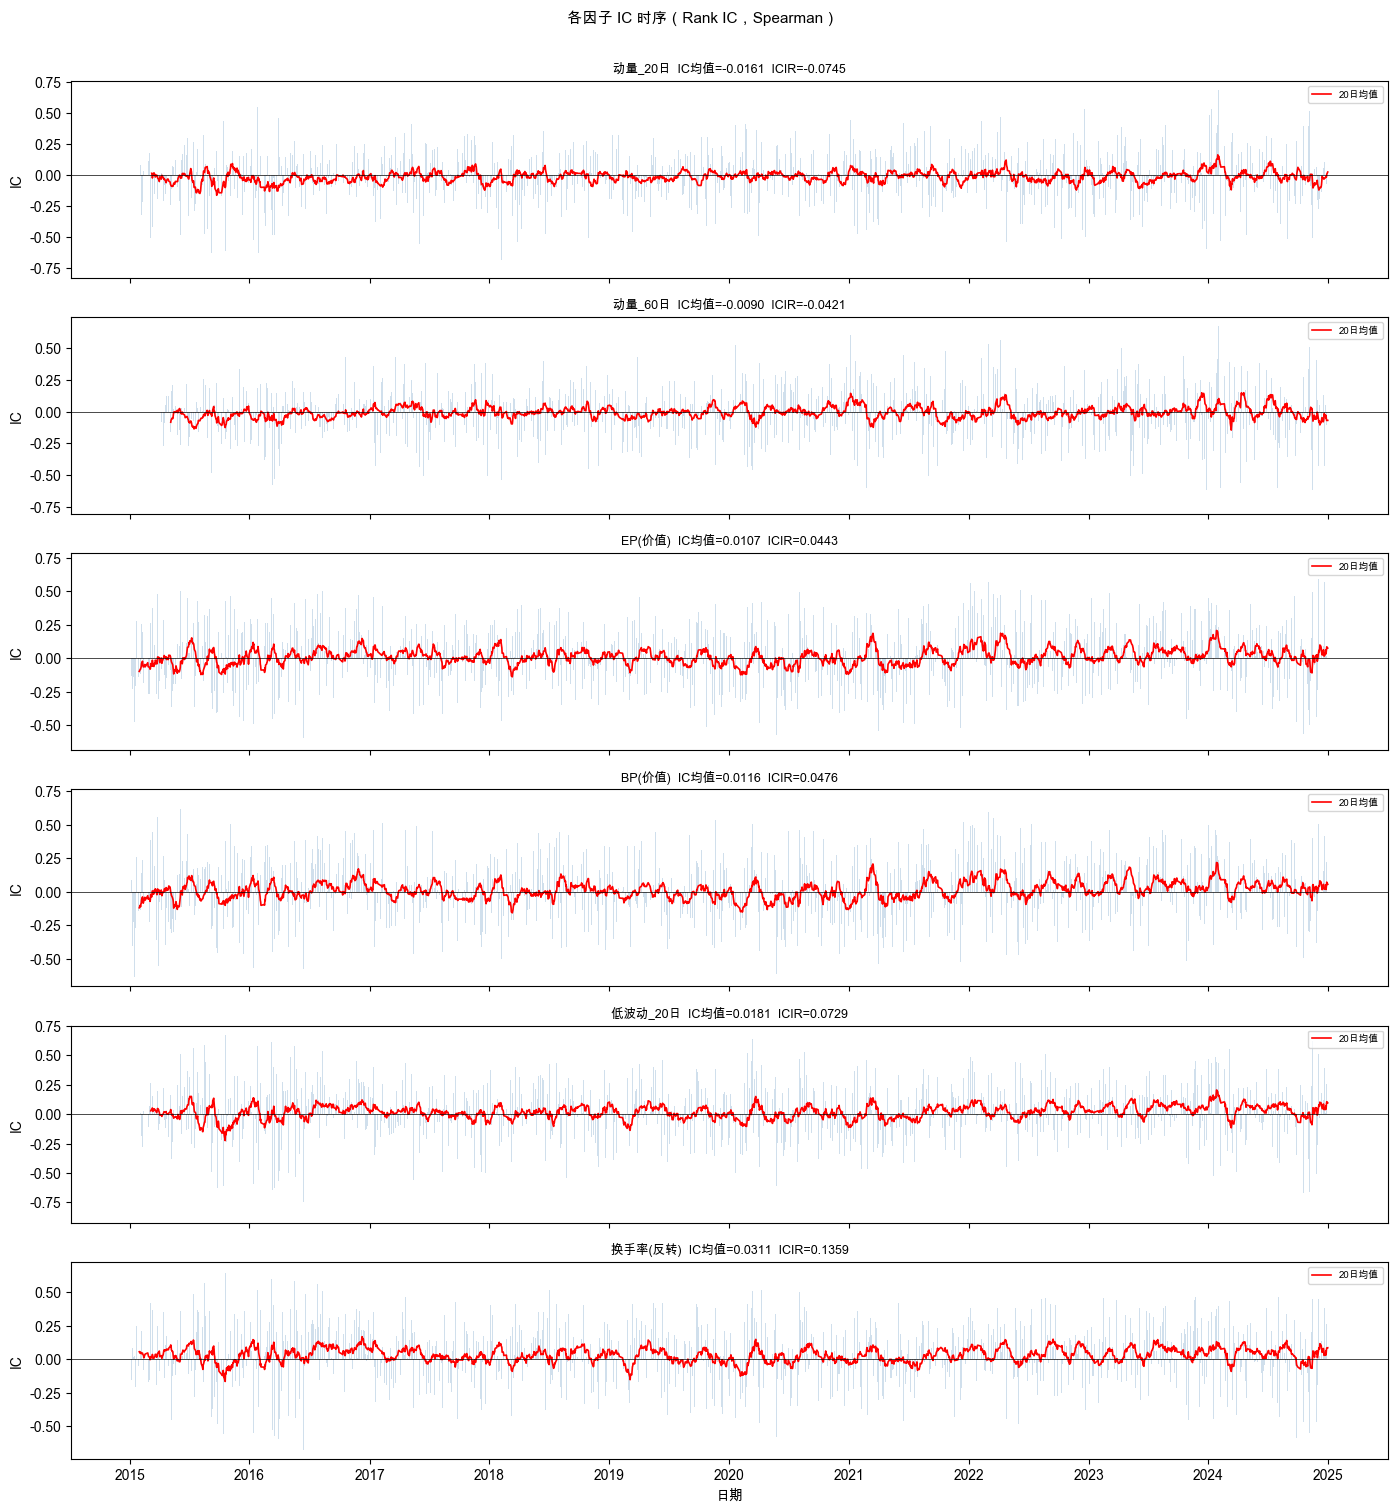

In [6]:
# IC 时序图
n_factors = len(all_factors)
fig, axes = plt.subplots(n_factors, 1, figsize=(14, 2.5 * n_factors), sharex=True)

for ax, (name, ic_s) in zip(axes, ic_series_dict.items()):
    ic_c = ic_s.dropna()
    ic_rolling = ic_c.rolling(20).mean()
    ax.bar(ic_c.index, ic_c.values, alpha=0.25, color='steelblue', width=1)
    ax.plot(ic_rolling.index, ic_rolling.values, color='red', linewidth=1.2, label='20日均值')
    ax.axhline(0, color='black', linewidth=0.5)
    mean_v = ic_c.mean()
    std_v  = ic_c.std()
    icir_v = mean_v / std_v if std_v > 0 else float('nan')
    ax.set_title(f'{name}  IC均值={mean_v:.4f}  ICIR={icir_v:.4f}', fontsize=9)
    ax.set_ylabel('IC')
    ax.legend(loc='upper right', fontsize=7)

axes[-1].set_xlabel('日期')
plt.suptitle('各因子 IC 时序（Rank IC，Spearman）', fontsize=11, y=1.005)
plt.tight_layout()
plt.show()

## Section 3：因子相关性矩阵

计算各因子截面值的时序相关性（按日期对齐后取均截面 Spearman 相关），判断因子是否正交。

低相关（|r| < 0.3）= 适合合成；高相关（|r| > 0.6）= 可能重复信息。

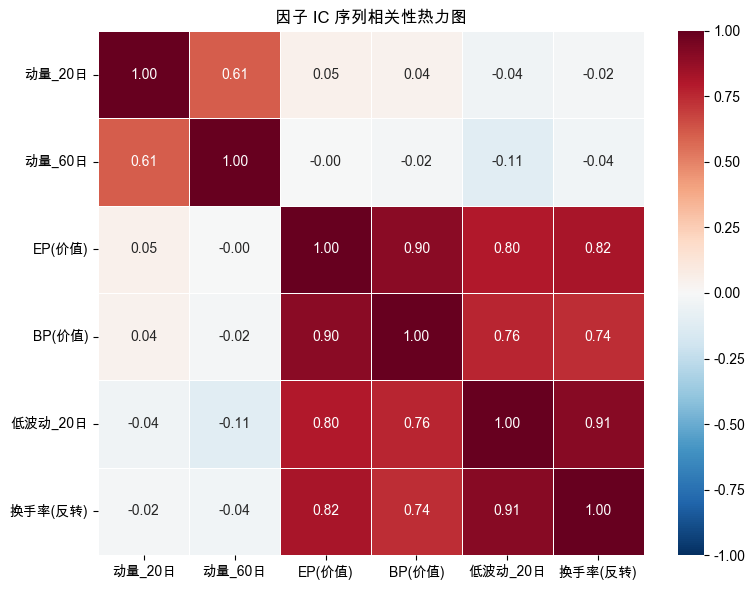


相关性矩阵（Spearman）:
         动量_20日  动量_60日  EP(价值)  BP(价值)  低波动_20日  换手率(反转)
动量_20日    1.000   0.608   0.047   0.041   -0.040   -0.020
动量_60日    0.608   1.000  -0.005  -0.019   -0.111   -0.037
EP(价值)    0.047  -0.005   1.000   0.903    0.799    0.824
BP(价值)    0.041  -0.019   0.903   1.000    0.758    0.737
低波动_20日  -0.040  -0.111   0.799   0.758    1.000    0.907
换手率(反转)  -0.020  -0.037   0.824   0.737    0.907    1.000


In [7]:
# 用 IC 时序的相关性近似因子相关性
ic_df = pd.DataFrame(ic_series_dict).dropna()

fig, ax = plt.subplots(figsize=(8, 6))
corr_mat = ic_df.corr(method='spearman')

mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, ax=ax, mask=False,
    linewidths=0.5, linecolor='white',
)
ax.set_title('因子 IC 序列相关性热力图', fontsize=12)
plt.tight_layout()
plt.show()

print('\n相关性矩阵（Spearman）:')
print(corr_mat.round(3).to_string())

## Section 4：多因子合成 + 五分位回测

筛选显著因子（|ICIR|>0.3 且 |t|>2），等权合成后：
1. 五分位回测
2. 对比 equal_weight vs risk_parity 仓位管理方案

In [8]:
# 筛选显著因子
sig_factors = {
    row['因子']: all_factors[row['因子']]
    for _, row in summary_df.iterrows()
    if row['是否显著'] == '✅'
}

if not sig_factors:
    print('⚠️  没有显著因子，使用全部因子合成')
    sig_factors = all_factors
else:
    print(f'✅ 显著因子: {list(sig_factors.keys())}')

# 等权合成：各因子截面排名后求均值
ranked_list = [cross_section_rank(fac) for fac in sig_factors.values()]
composite_factor = pd.concat(ranked_list).groupby(level=0).mean()
composite_factor = composite_factor.reindex(price_wide.index)

print(f'合成因子形状: {composite_factor.shape}')
print(f'有效率: {composite_factor.notna().mean().mean():.1%}')

⚠️  没有显著因子，使用全部因子合成
合成因子形状: (2431, 300)
有效率: 86.2%


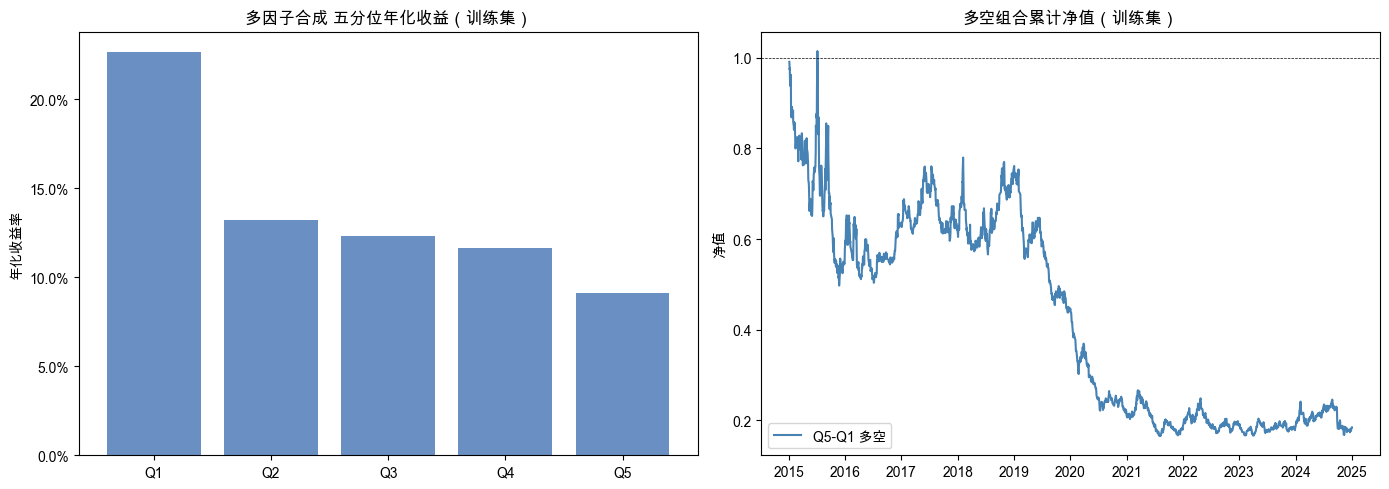

多空组合统计（训练集 2015-2024）:
  年化收益: -13.54%
  年化波动: 28.14%
  夏普比率: -0.481
  最大回撤: -83.67%


In [9]:
# 五分位回测
group_ret, ls_ret = quintile_backtest(
    composite_factor, ret_wide, n_groups=5, long_short='Qn_minus_Q1'
)

# 计算各分组累计净值
cum_group = (1 + group_ret.fillna(0)).cumprod()
cum_ls    = (1 + ls_ret.fillna(0)).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左：各组年化收益
avg_ret = group_ret.mean() * 252
colors = ['#d73027' if v < 0 else '#4575b4' for v in avg_ret.values]
axes[0].bar(avg_ret.index, avg_ret.values, color=colors, alpha=0.8)
axes[0].set_title('多因子合成 五分位年化收益（训练集）')
axes[0].set_ylabel('年化收益率')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))

# 右：多空净值曲线
axes[1].plot(cum_ls.index, cum_ls.values, color='steelblue', linewidth=1.5, label='Q5-Q1 多空')
axes[1].axhline(1, color='black', linewidth=0.5, linestyle='--')
axes[1].set_title('多空组合累计净值（训练集）')
axes[1].set_ylabel('净值')
axes[1].legend()

plt.tight_layout()
plt.show()

# 多空统计
ann_ret = ls_ret.mean() * 252
ann_vol = ls_ret.std() * np.sqrt(252)
sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan
max_dd  = (cum_ls / cum_ls.cummax() - 1).min()

print(f'多空组合统计（训练集 2015-2024）:')
print(f'  年化收益: {ann_ret:.2%}')
print(f'  年化波动: {ann_vol:.2%}')
print(f'  夏普比率: {sharpe:.3f}')
print(f'  最大回撤: {max_dd:.2%}')

运行 equal_weight 组合...


运行 risk_parity 组合...


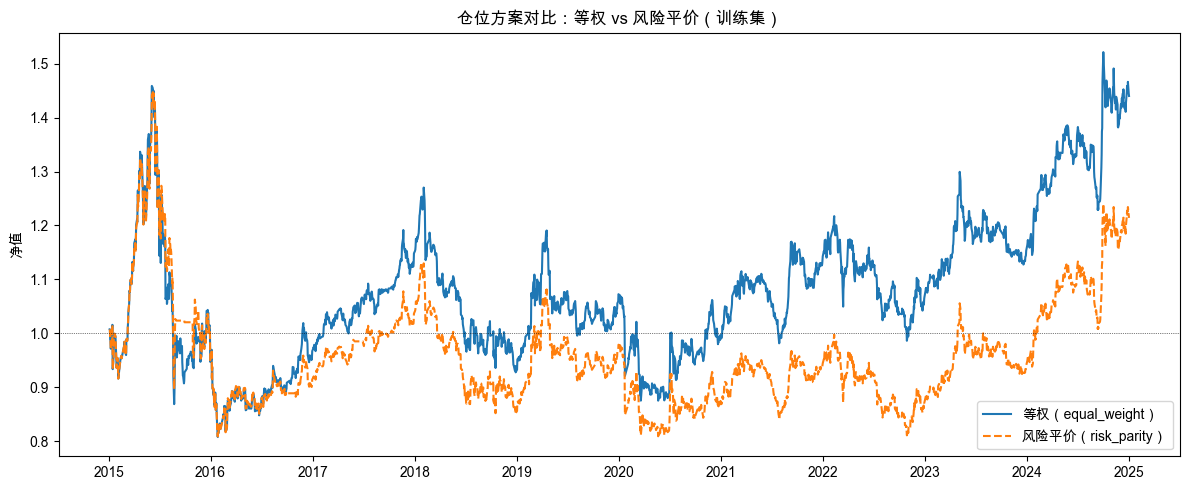

等权: 年化收益=5.70%  夏普=0.292  最大回撤=-44.66%
风险平价: 年化收益=3.70%  夏普=0.202  最大回撤=-44.14%


In [10]:
# 对比 equal_weight vs risk_parity 仓位方案
# 模拟每月调仓，选 Q5 组（因子最高的 20%）

def simulate_portfolio(
    factor_wide: pd.DataFrame,
    ret_wide: pd.DataFrame,
    n_stocks: int = 50,
    sizing: str = 'equal',
    rebalance_freq: str = 'ME',
) -> pd.Series:
    """
    按因子值选 top-N 股票，按指定方式分配仓位，计算组合日收益率。

    参数:
        factor_wide   : 因子宽表
        ret_wide      : 次日收益率宽表（已 shift(-1)）
        n_stocks      : 持仓数量
        sizing        : 'equal' 或 'risk_parity'
        rebalance_freq: pandas offset alias，如 'ME'=月末, 'QE'=季末

    返回:
        portfolio_ret: pd.Series，日收益率
    """
    # 计算调仓日期（月末或季末）
    rebalance_dates = factor_wide.resample(rebalance_freq).last().index

    # 计算每日波动率（用于 risk_parity）
    vol_wide = ret_wide.rolling(20).std()

    all_dates = factor_wide.index
    port_ret = pd.Series(index=all_dates, dtype=float)
    current_weights = {}

    for i, date in enumerate(all_dates):
        # 检查是否是调仓日
        if date in rebalance_dates or not current_weights:
            frow = factor_wide.loc[date].dropna()
            if len(frow) >= n_stocks:
                selected = frow.nlargest(n_stocks).index.tolist()
            else:
                selected = frow.index.tolist()

            if sizing == 'equal':
                current_weights = equal_weight(selected)
            else:
                vol_slice = vol_wide.loc[:date]
                current_weights = risk_parity(selected, vol_slice[selected] if selected else vol_slice)

        # 计算当日组合收益
        if not current_weights or date not in ret_wide.index:
            port_ret.iloc[i] = 0.0
            continue

        day_ret = ret_wide.loc[date]
        daily_port_ret = sum(
            w * day_ret.get(sym, 0.0)
            for sym, w in current_weights.items()
            if not pd.isna(day_ret.get(sym, np.nan))
        )
        # 扣除交易成本（月度调仓，双边 0.3% / 约 21 交易日）
        if date in rebalance_dates:
            daily_port_ret -= 0.003

        port_ret.iloc[i] = daily_port_ret

    return port_ret.fillna(0)


# 运行两种仓位方案
print('运行 equal_weight 组合...')
ret_equal = simulate_portfolio(composite_factor, ret_wide, n_stocks=50, sizing='equal')

print('运行 risk_parity 组合...')
ret_rp = simulate_portfolio(composite_factor, ret_wide, n_stocks=50, sizing='risk_parity')

cum_equal = (1 + ret_equal).cumprod()
cum_rp    = (1 + ret_rp).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cum_equal.index, cum_equal.values, label='等权（equal_weight）', linewidth=1.5)
ax.plot(cum_rp.index, cum_rp.values, label='风险平价（risk_parity）', linewidth=1.5, linestyle='--')
ax.axhline(1, color='black', linewidth=0.5, linestyle=':')
ax.set_title('仓位方案对比：等权 vs 风险平价（训练集）')
ax.set_ylabel('净值')
ax.legend()
plt.tight_layout()
plt.show()

for name, ret_s in [('等权', ret_equal), ('风险平价', ret_rp)]:
    ann_r = ret_s.mean() * 252
    ann_v = ret_s.std() * np.sqrt(252)
    sr    = ann_r / ann_v if ann_v > 0 else np.nan
    cum_s = (1 + ret_s).cumprod()
    dd    = (cum_s / cum_s.cummax() - 1).min()
    print(f'{name}: 年化收益={ann_r:.2%}  夏普={sr:.3f}  最大回撤={dd:.2%}')

## Section 5：样本外检验（2025 年）

用 2015-2024 训练的因子参数（无再优化），在 2025 年数据上验证有效性，检验过拟合风险。

In [11]:
# 加载 2025 样本外数据
try:
    price_oos = load_price_wide(symbols, OOS_START, OOS_END, field='close')
    pe_oos  = load_factor_wide(symbols, 'pe_ttm',   OOS_START, OOS_END)
    pb_oos  = load_factor_wide(symbols, 'pb',        OOS_START, OOS_END)
    tv_oos  = load_factor_wide(symbols, 'turnover',  OOS_START, OOS_END)

    if price_oos.shape[0] < 10:
        raise ValueError(f'样本外数据不足: {price_oos.shape[0]} 行')

    print(f'✅ 样本外数据加载成功: {price_oos.shape}')
    HAS_OOS = True

except Exception as e:
    print(f'⚠️  样本外数据不可用: {e}')
    print('   → 跳过样本外检验')
    HAS_OOS = False

✅ 样本外数据加载成功: (243, 300)


  样本内（IS）vs 样本外（OOS）因子 ICIR 对比
     因子  IS_IC均值  IS_ICIR  OOS_IC均值  OOS_ICIR  OOS_t统计
 动量_20日  -0.0161  -0.0745   -0.0148   -0.0648  -0.9629
 动量_60日  -0.0090  -0.0421   -0.0037   -0.0143  -0.1922
 EP(价值)   0.0107   0.0443    0.0225    0.0762   1.1848
 BP(价值)   0.0116   0.0476    0.0166    0.0673   1.0465
低波动_20日   0.0181   0.0729    0.0274    0.0967   1.4409
换手率(反转)   0.0311   0.1359    0.0287    0.1009   1.5690


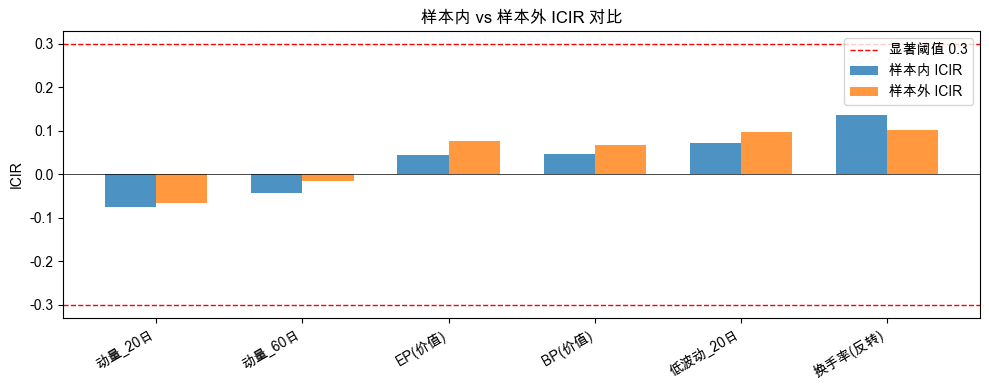

In [12]:
if HAS_OOS:
    # 构建样本外因子
    ret_oos_raw = price_oos.pct_change()
    ret_oos     = ret_oos_raw.shift(-1)

    mom20_oos  = price_oos.pct_change(20).shift(1)
    mom60_oos  = price_oos.pct_change(60).shift(1)
    ep_oos     = 1.0 / pe_oos.where(pe_oos > 0)
    bp_oos     = 1.0 / pb_oos.where(pb_oos > 0)
    lv_oos     = -ret_oos_raw.rolling(20).std()
    tv_factor_oos = -tv_oos

    oos_factors = {
        '动量_20日':  mom20_oos,
        '动量_60日':  mom60_oos,
        'EP(价值)':   ep_oos,
        'BP(价值)':   bp_oos,
        '低波动_20日': lv_oos,
        '换手率(反转)': tv_factor_oos,
    }

    # 样本外 IC 汇总
    oos_rows = []
    for name, fac in oos_factors.items():
        ic_s = compute_ic_series(fac, ret_oos, method='spearman', min_stocks=20)
        ic_c = ic_s.dropna()
        if len(ic_c) == 0:
            oos_rows.append({'因子': name, 'OOS_IC均值': np.nan, 'OOS_ICIR': np.nan, 'OOS_t统计': np.nan})
            continue
        mean_ic = ic_c.mean()
        std_ic  = ic_c.std()
        icir    = mean_ic / std_ic if std_ic > 0 else np.nan
        t_stat  = mean_ic / (std_ic / np.sqrt(len(ic_c))) if std_ic > 0 else np.nan
        oos_rows.append({'因子': name, 'OOS_IC均值': round(mean_ic, 4), 'OOS_ICIR': round(icir, 4), 'OOS_t统计': round(t_stat, 4)})

    oos_df = pd.DataFrame(oos_rows)

    # 合并样本内外对比
    compare_df = summary_df[['因子', 'IC均值', 'ICIR']].merge(oos_df, on='因子')
    compare_df.columns = ['因子', 'IS_IC均值', 'IS_ICIR', 'OOS_IC均值', 'OOS_ICIR', 'OOS_t统计']

    print('=' * 70)
    print('  样本内（IS）vs 样本外（OOS）因子 ICIR 对比')
    print('=' * 70)
    print(compare_df.to_string(index=False))

    # 可视化
    fig, ax = plt.subplots(figsize=(10, 4))
    x = np.arange(len(compare_df))
    w = 0.35
    ax.bar(x - w/2, compare_df['IS_ICIR'],  width=w, label='样本内 ICIR',  alpha=0.8)
    ax.bar(x + w/2, compare_df['OOS_ICIR'], width=w, label='样本外 ICIR', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(compare_df['因子'], rotation=30, ha='right')
    ax.axhline(0.3, color='red', linewidth=1, linestyle='--', label='显著阈值 0.3')
    ax.axhline(-0.3, color='red', linewidth=1, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title('样本内 vs 样本外 ICIR 对比')
    ax.set_ylabel('ICIR')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('跳过：样本外数据不可用')

## Section 6：因子换手率分析

分析各因子的调仓频率（换手率），换手率过高意味着交易成本侵蚀 alpha。

`compute_factor_turnover`：计算相邻两期持仓的换手率，定义为每期前后 top-N 持仓差异比例。

动量_20日         : 平均月换手率 = 77.87%  (观测期数=79)
动量_60日         : 平均月换手率 = 54.67%  (观测期数=78)
EP(价值)         : 平均月换手率 = 7.57%  (观测期数=79)
BP(价值)         : 平均月换手率 = 6.35%  (观测期数=79)
低波动_20日        : 平均月换手率 = 43.72%  (观测期数=79)
换手率(反转)        : 平均月换手率 = 28.81%  (观测期数=79)


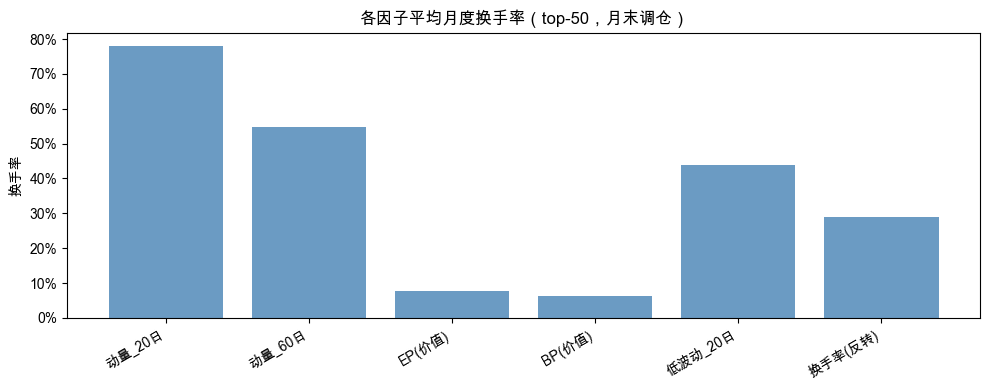

In [13]:
def compute_factor_turnover(
    factor_wide: pd.DataFrame,
    n_stocks: int = 50,
    rebalance_freq: str = 'ME',
) -> pd.Series:
    """
    计算因子持仓换手率序列。

    定义：换手率 = 相邻两期持仓中不重叠个股数 / n_stocks
    即有多少比例的持仓被替换。

    参数:
        factor_wide   : 因子宽表 (date × symbol)
        n_stocks      : 每期持股数
        rebalance_freq: 调仓频率，'ME'=月末, 'QE'=季末

    返回:
        turnover_series: pd.Series，每个调仓日的换手率
    """
    rebalance_dates = factor_wide.resample(rebalance_freq).last().index

    prev_holding = set()
    turnover_list = []

    for date in rebalance_dates:
        if date not in factor_wide.index:
            continue
        frow = factor_wide.loc[date].dropna()
        if len(frow) < n_stocks:
            continue
        curr_holding = set(frow.nlargest(n_stocks).index.tolist())

        if prev_holding:
            # 换手率 = 新增持仓数 / 持仓数（单边换手）
            new_stocks = curr_holding - prev_holding
            to_rate = len(new_stocks) / n_stocks
            turnover_list.append({'date': date, 'turnover': to_rate})

        prev_holding = curr_holding

    if not turnover_list:
        return pd.Series(dtype=float, name='factor_turnover')

    df_to = pd.DataFrame(turnover_list).set_index('date')['turnover']
    df_to.name = 'factor_turnover'
    return df_to


# 计算各因子换手率
to_results = {}
for name, fac in all_factors.items():
    to_s = compute_factor_turnover(fac, n_stocks=50, rebalance_freq='ME')
    to_results[name] = to_s
    print(f'{name:15s}: 平均月换手率 = {to_s.mean():.2%}  (观测期数={len(to_s)})')

# 可视化
fig, ax = plt.subplots(figsize=(10, 4))
means = {k: v.mean() for k, v in to_results.items()}
ax.bar(list(means.keys()), list(means.values()), alpha=0.8, color='steelblue')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_title('各因子平均月度换手率（top-50，月末调仓）')
ax.set_ylabel('换手率')
ax.set_xticklabels(list(means.keys()), rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Section 7：止损影响分析

测试不同止损策略对多空组合收益的影响：
- `trailing_stop`：个股跌幅止损（从高点回撤超阈值）
- `portfolio_stop`：组合止损（累计回撤超阈值）

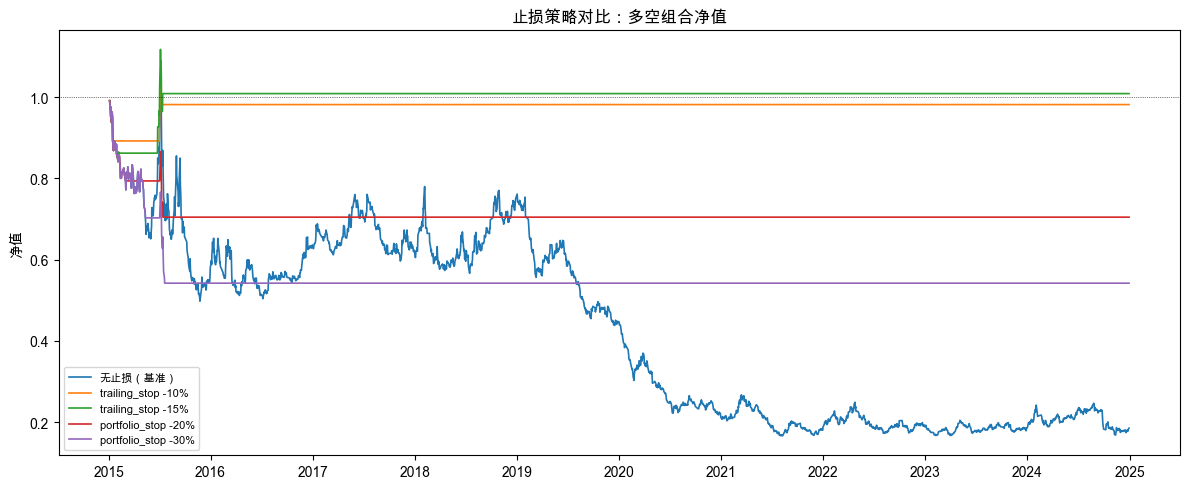


策略                           年化收益       年化波动       夏普       最大回撤     止损天数
------------------------------------------------------------------------
无止损（基准）                   -13.54%     28.14%   -0.481    -83.67%        0
trailing_stop -10%         -0.09%      4.67%   -0.018     -9.99%     2415
trailing_stop -15%          0.30%      6.52%    0.046    -14.45%     2395
portfolio_stop -20%        -3.45%      6.05%   -0.570    -28.92%     2385
portfolio_stop -30%        -6.04%      7.85%   -0.770    -45.32%     2332


In [14]:
# 基准：多空组合日收益
base_ret = ls_ret.dropna()

# 应用不同止损策略
ret_trailing_10 = trailing_stop(base_ret, threshold=-0.10)
ret_trailing_15 = trailing_stop(base_ret, threshold=-0.15)
ret_portfolio_20 = portfolio_stop(base_ret, max_drawdown=-0.20)
ret_portfolio_30 = portfolio_stop(base_ret, max_drawdown=-0.30)

strategies = {
    '无止损（基准）':      base_ret,
    'trailing_stop -10%': ret_trailing_10,
    'trailing_stop -15%': ret_trailing_15,
    'portfolio_stop -20%': ret_portfolio_20,
    'portfolio_stop -30%': ret_portfolio_30,
}

# 净值曲线
fig, ax = plt.subplots(figsize=(12, 5))
for strat_name, ret_s in strategies.items():
    cum_s = (1 + ret_s.fillna(0)).cumprod()
    ax.plot(cum_s.index, cum_s.values, label=strat_name, linewidth=1.2)
ax.axhline(1, color='black', linewidth=0.5, linestyle=':')
ax.set_title('止损策略对比：多空组合净值')
ax.set_ylabel('净值')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# 统计对比表
print(f'\n{"策略":<22} {"年化收益":>10} {"年化波动":>10} {"夏普":>8} {"最大回撤":>10} {"止损天数":>8}')
print('-' * 72)
for strat_name, ret_s in strategies.items():
    r_c = ret_s.fillna(0)
    ann_r = r_c.mean() * 252
    ann_v = r_c.std() * np.sqrt(252)
    sr    = ann_r / ann_v if ann_v > 0 else np.nan
    cum_c = (1 + r_c).cumprod()
    dd    = (cum_c / cum_c.cummax() - 1).min()
    zeros = (r_c == 0).sum()
    print(f'{strat_name:<22} {ann_r:>10.2%} {ann_v:>10.2%} {sr:>8.3f} {dd:>10.2%} {zeros:>8d}')

## Section 8：参数敏感性网格搜索

对以下参数组合进行网格搜索，评估策略稳健性：
- `n_stocks`: [20, 30, 50, 100]
- `rebalance`: ['monthly', 'quarterly']

输出每种组合的年化收益、夏普比率、最大回撤。

In [15]:
N_STOCKS_GRID  = [20, 30, 50, 100]
REBALANCE_GRID = ['monthly', 'quarterly']
REBALANCE_MAP  = {'monthly': 'ME', 'quarterly': 'QE'}

grid_rows = []

for n_stocks, rebal in product(N_STOCKS_GRID, REBALANCE_GRID):
    freq = REBALANCE_MAP[rebal]
    try:
        ret_s = simulate_portfolio(
            composite_factor, ret_wide,
            n_stocks=n_stocks,
            sizing='equal',
            rebalance_freq=freq,
        )
        ann_r = ret_s.mean() * 252
        ann_v = ret_s.std() * np.sqrt(252)
        sr    = ann_r / ann_v if ann_v > 0 else np.nan
        cum_s = (1 + ret_s).cumprod()
        dd    = (cum_s / cum_s.cummax() - 1).min()
        grid_rows.append({
            'n_stocks':   n_stocks,
            'rebalance':  rebal,
            '年化收益':   round(ann_r, 4),
            '夏普比率':   round(sr,    3),
            '最大回撤':   round(dd,    4),
        })
        print(f'n={n_stocks:3d}, {rebal:10s}: 年化={ann_r:.2%}  夏普={sr:.3f}  回撤={dd:.2%}')
    except Exception as e:
        print(f'n={n_stocks:3d}, {rebal:10s}: ❌ {e}')
        grid_rows.append({'n_stocks': n_stocks, 'rebalance': rebal, '年化收益': np.nan, '夏普比率': np.nan, '最大回撤': np.nan})

grid_df = pd.DataFrame(grid_rows)
print()
print('=' * 60)
print('  参数网格搜索结果汇总')
print('=' * 60)
print(grid_df.to_string(index=False))

n= 20, monthly   : 年化=2.80%  夏普=0.148  回撤=-41.21%


n= 20, quarterly : 年化=5.67%  夏普=0.296  回撤=-32.35%


n= 30, monthly   : 年化=5.07%  夏普=0.266  回撤=-37.53%


n= 30, quarterly : 年化=7.08%  夏普=0.364  回撤=-38.70%


n= 50, monthly   : 年化=5.70%  夏普=0.292  回撤=-44.66%


n= 50, quarterly : 年化=7.46%  夏普=0.372  回撤=-45.81%


n=100, monthly   : 年化=6.17%  夏普=0.300  回撤=-47.64%


n=100, quarterly : 年化=7.83%  夏普=0.377  回撤=-46.66%

  参数网格搜索结果汇总
 n_stocks rebalance   年化收益  夏普比率    最大回撤
       20   monthly 0.0280 0.148 -0.4121
       20 quarterly 0.0567 0.296 -0.3235
       30   monthly 0.0507 0.266 -0.3753
       30 quarterly 0.0708 0.364 -0.3870
       50   monthly 0.0570 0.292 -0.4466
       50 quarterly 0.0746 0.372 -0.4581
      100   monthly 0.0617 0.300 -0.4764
      100 quarterly 0.0783 0.377 -0.4666


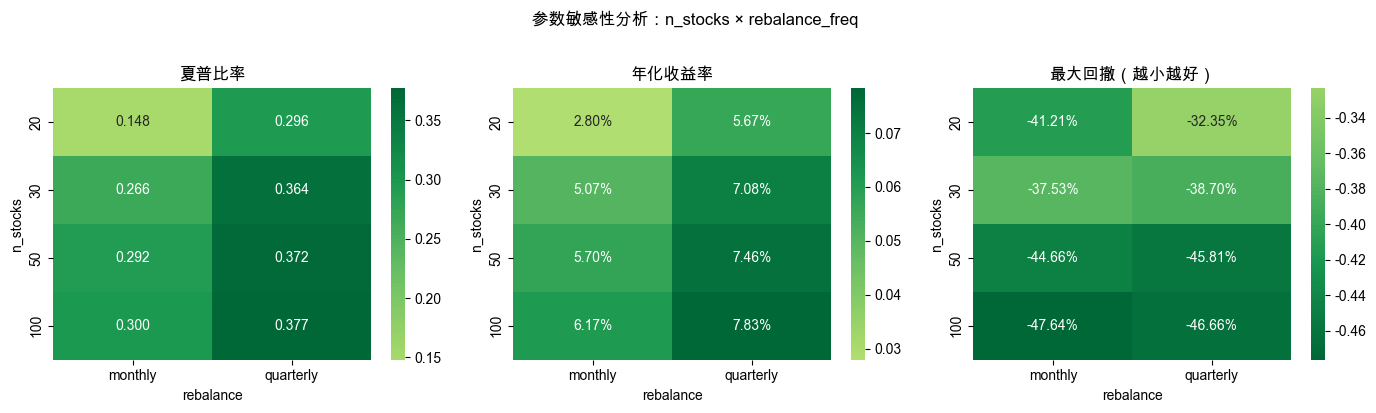


最优参数（按夏普比率）: n_stocks=100, rebalance=quarterly
  年化收益=7.83%, 夏普=0.377, 最大回撤=-46.66%


In [16]:
# 热力图可视化
pivot_sharpe = grid_df.pivot(index='n_stocks', columns='rebalance', values='夏普比率')
pivot_ann    = grid_df.pivot(index='n_stocks', columns='rebalance', values='年化收益')
pivot_dd     = grid_df.pivot(index='n_stocks', columns='rebalance', values='最大回撤')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.heatmap(pivot_sharpe, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0], center=0)
axes[0].set_title('夏普比率')

sns.heatmap(pivot_ann, annot=True, fmt='.2%', cmap='RdYlGn', ax=axes[1], center=0)
axes[1].set_title('年化收益率')

sns.heatmap(pivot_dd, annot=True, fmt='.2%', cmap='RdYlGn_r', ax=axes[2], center=-0.2)
axes[2].set_title('最大回撤（越小越好）')

plt.suptitle('参数敏感性分析：n_stocks × rebalance_freq', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

# 最优参数
best_idx = grid_df['夏普比率'].idxmax()
if pd.notna(best_idx):
    best = grid_df.loc[best_idx]
    print(f'\n最优参数（按夏普比率）: n_stocks={best["n_stocks"]}, rebalance={best["rebalance"]}')
    print(f'  年化收益={best["年化收益"]:.2%}, 夏普={best["夏普比率"]:.3f}, 最大回撤={best["最大回撤"]:.2%}')

In [17]:
# 最终结论汇总
print('=' * 70)
print('  因子验证结论汇总')
print('=' * 70)
print()
print('【显著因子（|ICIR|>0.3 且 |t|>2）】')
sig_rows = summary_df[summary_df['是否显著'] == '✅']
if sig_rows.empty:
    print('  无显著因子（可能数据不足或市场有效）')
else:
    print(sig_rows[['因子', 'IC均值', 'ICIR', 't统计量']].to_string(index=False))

print()
print('【多因子合成组合（equal_weight，50持仓，月度调仓）】')
eq_r = ret_equal.fillna(0)
eq_ann = eq_r.mean() * 252
eq_vol = eq_r.std() * np.sqrt(252)
eq_sr  = eq_ann / eq_vol if eq_vol > 0 else np.nan
eq_cum = (1 + eq_r).cumprod()
eq_dd  = (eq_cum / eq_cum.cummax() - 1).min()
print(f'  年化收益: {eq_ann:.2%}')
print(f'  夏普比率: {eq_sr:.3f}')
print(f'  最大回撤: {eq_dd:.2%}')

print()
print('【策略评审门槛（WORKFLOW.md）】')
print(f'  年化收益 > 15%: {"✅" if eq_ann > 0.15 else "❌"}  ({eq_ann:.2%})')
print(f'  夏普比率 > 0.8: {"✅" if eq_sr  > 0.80 else "❌"}  ({eq_sr:.3f})')
print(f'  最大回撤 < 30%: {"✅" if eq_dd  > -0.30 else "❌"} ({eq_dd:.2%})')
print()
print('=' * 70)

  因子验证结论汇总

【显著因子（|ICIR|>0.3 且 |t|>2）】
  无显著因子（可能数据不足或市场有效）

【多因子合成组合（equal_weight，50持仓，月度调仓）】
  年化收益: 5.70%
  夏普比率: 0.292
  最大回撤: -44.66%

【策略评审门槛（WORKFLOW.md）】
  年化收益 > 15%: ❌  (5.70%)
  夏普比率 > 0.8: ❌  (0.292)
  最大回撤 < 30%: ❌ (-44.66%)

